In [1]:
import os
import numpy as np
import json
import utm
import csv
from scipy.spatial import distance
from scipy.interpolate import interp1d

seq_names = ['00']

osm = True
lidar = True

num_bin = 360
sensor_range = 50
bin_size = 5  # bin size of rotation-invariant descriptor

def interpolate_road_coords(x_coords, y_coords):
    """
    使用与MATLAB相似的方式插值道路坐标
    """
    interp_x, interp_y = [], []
    for i in range(len(x_coords)-1):
        x1, x2 = x_coords[i], x_coords[i+1]
        y1, y2 = y_coords[i], y_coords[i+1]
        dx = x1-x2
        dy = y1-y2
        step = abs(dx/np.sqrt(dx**2+dy**2))
        
        itp_x = np.arange(min(x1,x2), max(x1,x2)+step, step)
        if len(interp_x) > 0 and itp_x[0] == interp_x[-1]:
            itp_x = itp_x[1:]
        
        f = interp1d([x1, x2], [y1, y2])
        itp_y = f(itp_x)
        
        interp_x.extend(itp_x)
        interp_y.extend(itp_y)
    
    return np.array(interp_x), np.array(interp_y)


for seq_name in seq_names:
    print(f'KITTI sequence {seq_name} start.')

    # Load OSM files
    building_file_name = f'/data/Pcmaploc/data/hand_crafted_data/kitti{seq_name}_buildings.geojson'
    road_file_name = f'/data/Pcmaploc/data/hand_crafted_data/kitti{seq_name}_roads.geojson'
    osm_save_path = f'/data/Pcmaploc/data/hand_crafted_data/kitti{seq_name}_osm_descriptor.csv'
    osm_rotinv_save_path = f'/data/Pcmaploc/data/hand_crafted_data/kitti{seq_name}_rotinv_osm_descriptor.csv'

    with open(building_file_name, 'r') as f:
        building_val = json.load(f)
    
    with open(road_file_name, 'r') as f:
        road_val = json.load(f)






KITTI sequence 00 start.


In [8]:
for feature in building_val['features']:
    geometry = feature['geometry']
    coordinates = geometry['coordinates']
    if isinstance(coordinates, list):
        print(len(coordinates))
        print(len(coordinates[0]))
        print(len(coordinates[0][0]))
        print(coordinates[0][0])
    break
    # print(coords_out)

1
2
13
[[8.3920297, 48.9802337], [8.3921094, 48.9803072], [8.3922215, 48.9802548], [8.3923339, 48.9803585], [8.3922213, 48.9804111], [8.3923003, 48.9804839], [8.3928368, 48.9802333], [8.3927591, 48.9801616], [8.3926428, 48.9802159], [8.3925311, 48.9801129], [8.3926466, 48.9800589], [8.3925649, 48.9799836], [8.3920297, 48.9802337]]


In [ ]:
# 投影所有的building的坐标
x_coords_out = []
y_coords_out = []
for feature in building_val['features']:
    geometry = feature['geometry']
    coordinates = geometry['coordinates']
    if isinstance(coordinates, list):
        coords_out = np.array(coordinates)
    else:
        coords_out = np.array(coordinates).reshape(-1, 2)

    x_coords_out_temp, y_coords_out_temp = utm.from_latlon(coords_out[:, 1], coords_out[:, 0])[:2]
    x_coords_out.append(x_coords_out_temp)
    y_coords_out.append(y_coords_out_temp)

Generate building points

In [9]:
import pykitti
import numpy as np
import os
from tqdm import tqdm  # 导入 tqdm 库

# 定义路径
base_path = '/data/Pcmaploc/data/kitti/data_odometry_velodyne/dataset'
seq_list = ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10']

# 定义建筑物标签值
BUILDING_LABEL = 50

# 定义输出路径
output_path = '/data/Pcmaploc/data/kitti/building_pointclouds'
os.makedirs(output_path, exist_ok=True)

for seq in seq_list:
    print(f"\nProcessing sequence {seq}...")
    dataset = pykitti.odometry(base_path, seq)

    label_dir = os.path.join(base_path, 'sequences', seq, 'labels')
    if not os.path.exists(label_dir):
        print(f"Label directory for sequence {seq} not found. Skipping...")
        continue

    seq_output_path = os.path.join(output_path, seq)
    os.makedirs(seq_output_path, exist_ok=True)

    for i, pc in enumerate(tqdm(dataset.velo, desc=f"Sequence {seq}", unit="frame")):
        label_file = os.path.join(label_dir, f"{i:06d}.label")

        # if not os.path.exists(label_file):
        #     print(f"Label file {label_file} not found. Skipping frame {i}...")
        #     continue

        labels = np.fromfile(label_file, dtype=np.uint32)
        labels = labels & 0xFFFF 

        pc = np.asarray(pc) 
        building_points = pc[labels == BUILDING_LABEL]

        output_file = os.path.join(seq_output_path, f"{i:06d}_building.npy")
        np.save(output_file, building_points)

print("Processing complete.")



Processing sequence 00...


Sequence 00: 17frame [00:00, 50.73frame/s]

Sequence 00: 4541frame [02:13, 33.93frame/s]



Processing sequence 01...


Sequence 01: 1101frame [00:41, 26.32frame/s]


...


Processing sequence 09...


Sequence 09: 1591frame [01:07, 23.46frame/s]



Processing sequence 10...


Sequence 10: 1201frame [00:50, 23.74frame/s]

Processing complete.


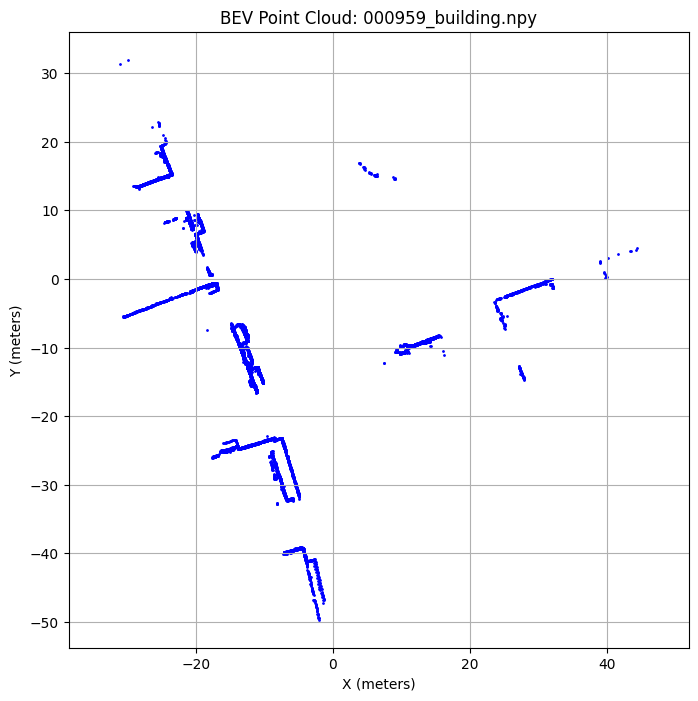

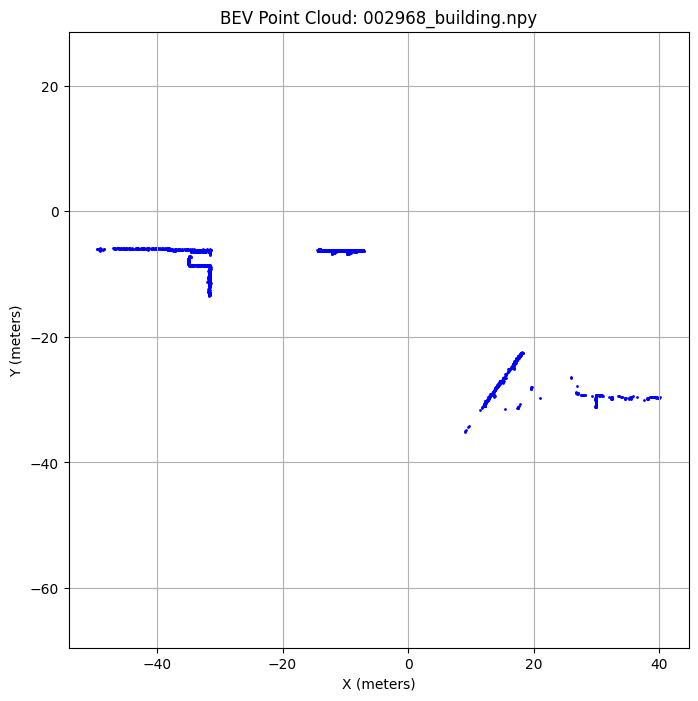

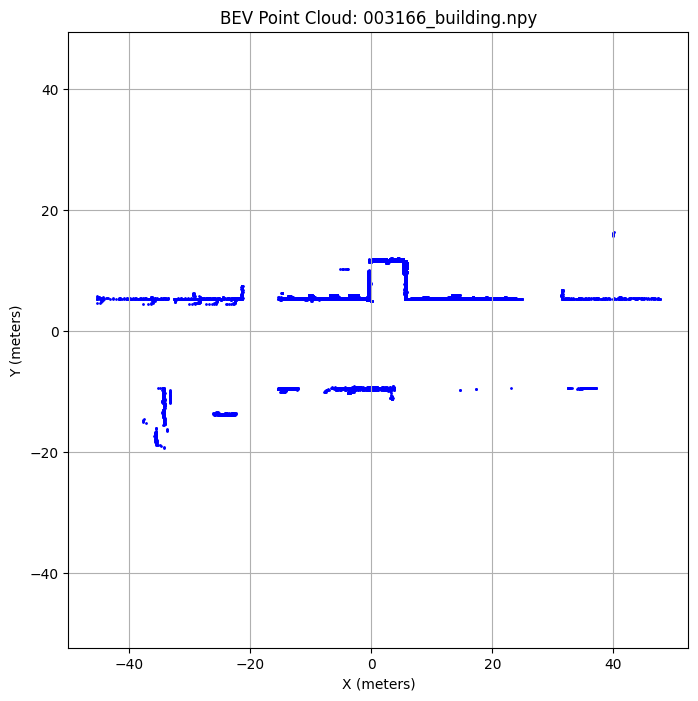

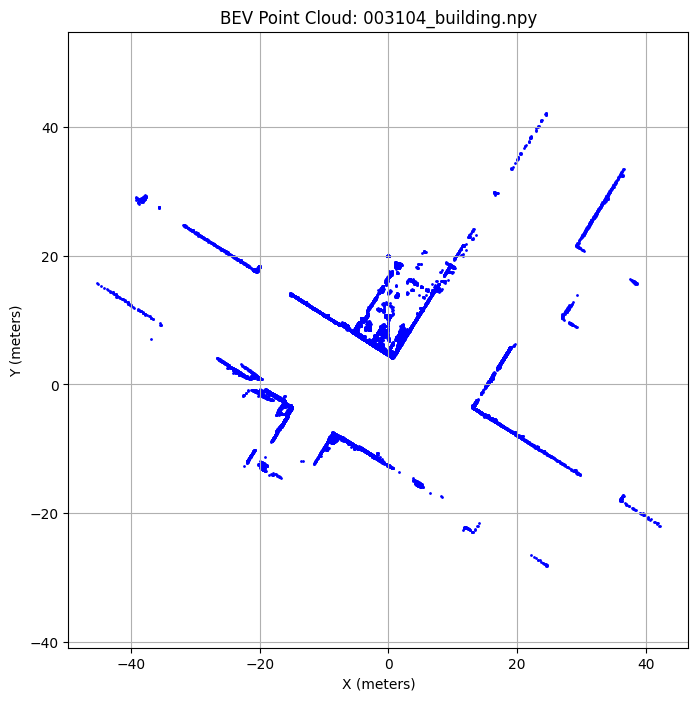

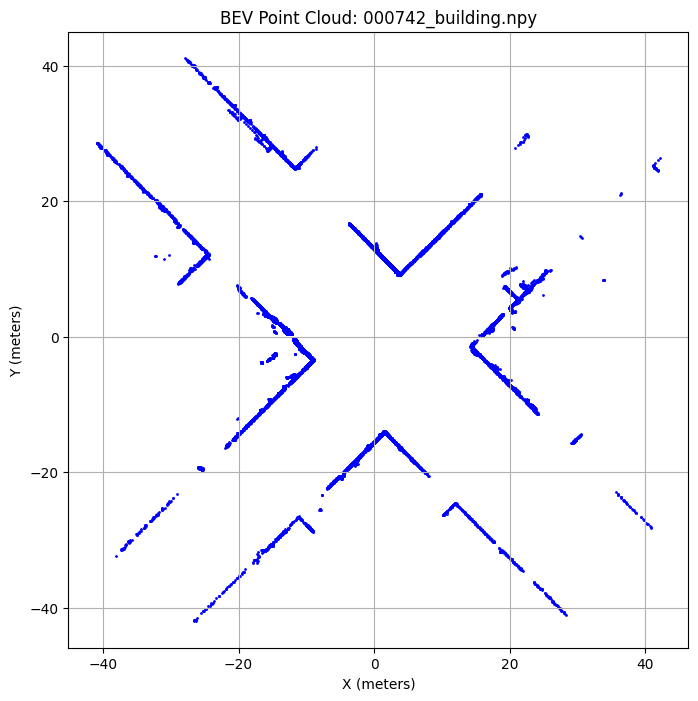

In [10]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt

# 定义路径
sequence = '00'
data_path = f'/data/Pcmaploc/data/kitti/building_pointclouds/{sequence}'

# 获取所有保存的点云文件
pointcloud_files = [f for f in os.listdir(data_path) if f.endswith('_building.npy')]

# 随机选择 5 个点云文件
random_files = random.sample(pointcloud_files, 5)

# 可视化随机选择的 5 帧点云（BEV）
for file in random_files:
    # 加载点云数据
    file_path = os.path.join(data_path, file)
    pointcloud = np.load(file_path)

    # 检查点云是否为空
    if pointcloud.shape[0] == 0:
        print(f"File {file} has no points. Skipping...")
        continue

    # 提取 x, y 坐标
    x = pointcloud[:, 0]
    y = pointcloud[:, 1]

    # 创建 2D 图形
    plt.figure(figsize=(8, 8))
    plt.scatter(x, y, s=1, c='blue')  # 点大小为 1，颜色为蓝色
    plt.title(f"BEV Point Cloud: {file}")
    plt.xlabel("X (meters)")
    plt.ylabel("Y (meters)")
    plt.axis("equal")  # 保持轴比例一致
    plt.grid(True)

    # 显示图像
    plt.show()


In [19]:
osm_desc_path = '/data/Pcmaploc/data/hand_crafted_data/kitti00_osm_descriptor.npy'
osm_desc = np.load(osm_desc_path)
print(osm_desc[104])

[ 0.          0.         38.0964923  37.97225842 37.8603273  37.76052253
 37.67268787 37.59668663  0.          0.          0.          0.
  0.          0.          0.         25.63722109 25.75335309 25.87846069
 26.01275216 26.15645374 26.30981058 26.47308781 26.64657178 26.83057126
 27.02541896 27.23147303 27.44911886 27.6787709  27.92087485 28.17590988
 28.44439126  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         35.26233821
  0.         41.6165683  41.98563628 42.37433196 42.78344588 43.21382828
  0.         40.51694931  0.          0.          0.         43.5005223
 44.60052986 45.77191727 47.02120434 48.35574334 41.97916967  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.         25.71123265 25.69039077 25.67739791
 25.67223424 25.67489189 25

In [22]:
pc_desc_path = '/data/Pcmaploc/data/hand_crafted_data/kitti00_lidar_descriptor.npy'
pc_desc = np.load(pc_desc_path)
print(pc_desc[0])

[ 0.          0.          0.          0.          0.          0.
  0.          0.         44.34311676 38.9620285  34.5841713  34.54573059
 28.17431831 25.35392761 23.49878693 21.96398926 20.82559586 19.38045883
 17.50436211 17.04513359 16.54302788 15.0123415  14.52174187 14.21625519
 13.67285442 13.11104679 12.5643177  12.18704605 12.08217335 12.17261219
 12.27104759 12.3989172  12.38407421 12.6666851  12.8096199  12.95204163
 13.10263348 13.26546097 13.43997002 13.62458229 13.80437279 13.93387032
 14.22400284 14.43433762 14.57052135 14.8431406  15.11939621 15.38107681
  7.25168037  7.05553675  6.98334599  6.86560345  6.76403666  6.67621183
  6.61695814  6.51918507  6.4503212   6.36168337  6.28593969  6.15278101
  5.96275616  5.92764902  5.89503527  5.85892773  5.80779362  5.76669884
  5.80415297  5.77813721  5.7279892   5.68487835  5.65095758  5.59523439
  5.57679462  5.52883339  5.48628426  5.47141361  5.42020941  5.37535238
  5.3425355   5.10817051  5.12607288  5.10413218  5.2040667

In [3]:
import numpy as np
osm_pose_path = f'/data/Pcmaploc/data/hand_crafted_data/kitti00_osm_pose.npy'

osm_pose = np.load(osm_pose_path)
print(osm_pose[1000])

[ 455654.35490437 5426010.50277994]


[[ 1.000000e+00  9.043680e-12  2.326809e-11  5.551115e-17]
 [ 9.043683e-12  1.000000e+00  2.392370e-10  3.330669e-16]
 [ 2.326810e-11  2.392370e-10  9.999999e-01 -4.440892e-16]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]


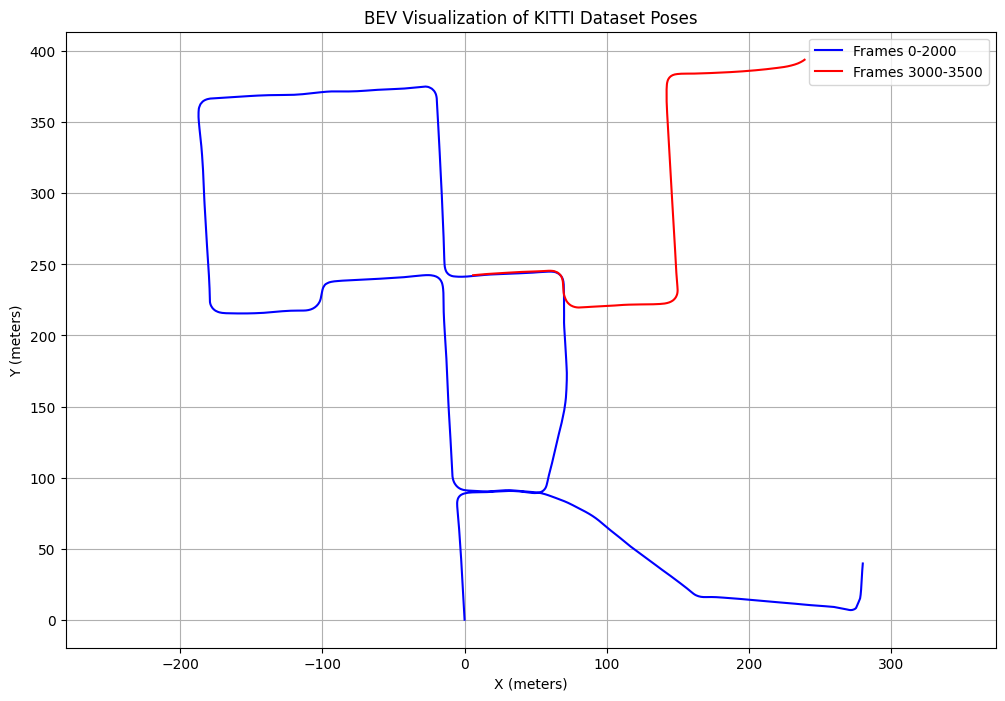

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pykitti

# Load the dataset
seq = '00'
dataset = pykitti.odometry('/data/Pcmaploc/data/kitti/data_odometry_velodyne/dataset', seq)

# Extract poses for visualization
poses = dataset.poses
print(poses[0])
# Convert poses to BEV (Bird's Eye View) coordinates
def extract_bev_coordinates(poses):
    coords = np.array([[pose[0, 3], pose[2, 3]] for pose in poses])
    return coords

# Extract coordinates for the desired frames
coords_part1 = extract_bev_coordinates(poses[:2000])  # First 2000 frames
coords_part2 = extract_bev_coordinates(poses[3000:3501])  # Frames 3000-3500
# print(coords_part1)
# Visualization
plt.figure(figsize=(12, 8))

# Plot first part
plt.plot(coords_part1[:, 0], coords_part1[:, 1], label="Frames 0-2000", color="blue")

# Plot second part
plt.plot(coords_part2[:, 0], coords_part2[:, 1], label="Frames 3000-3500", color="red")

# Add labels, legend, and grid
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title("BEV Visualization of KITTI Dataset Poses")
plt.legend()
plt.grid(True)

# Display the plot
plt.axis('equal')
plt.show()
